In [1]:
!pip install medmnist scikit-learn matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 97.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 

# Etapa 5 — Modelo Final: Avaliação Oficial no Conjunto de Teste

Carrega o **EfficientNet-B0 Fine-tuning** (melhor modelo identificado na validação do Notebook 03).

> ⚠ **Regra metodológica**: conjunto de teste usado **uma única vez**.

In [2]:
# ============================================================
# CÉLULA 1 — Seeds, Imports e Dispositivo
# ============================================================
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
from medmnist import PathMNIST
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score,
)

SEED = 42
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED);    random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')

NOMES_CLASSES = [
    'Adiposo', 'Fundo', 'Debris', 'Linfócitos',
    'Muco', 'Músculo', 'Normal', 'Estroma', 'Tumor',
]

Dispositivo: cuda


In [3]:
# ============================================================
# CÉLULA 2 — Construir EfficientNet-B0 e Carregar Pesos
# ============================================================

# Caminho do .pth no Kaggle (dataset adicionado como input)
PESOS_PATH = '/kaggle/input/datasets/dheriisousa/pesos-efficientnet/EfficientNetB0_FT.pth'

# Reconstrói a mesma arquitetura do Notebook 03
modelo_final = models.efficientnet_b0(weights=None)
in_features  = modelo_final.classifier[1].in_features
modelo_final.classifier[1] = nn.Linear(in_features, 9)
modelo_final = modelo_final.to(DEVICE)

modelo_final.load_state_dict(torch.load(PESOS_PATH, map_location=DEVICE))
modelo_final.eval()
print(f'✅ Pesos carregados: {PESOS_PATH}')

✅ Pesos carregados: /kaggle/input/datasets/dheriisousa/pesos-efficientnet/EfficientNetB0_FT.pth


In [4]:
# ============================================================
# CÉLULA 3 — DataLoader de Teste (ISOLADO)
# ============================================================
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

print('Carregando conjunto de teste...')
ds_test     = PathMNIST(split='test', size=224, download=True, transform=transform_test)
test_loader = DataLoader(ds_test, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)
print(f'Total de imagens no teste: {len(ds_test)}')

Carregando conjunto de teste...


100%|██████████| 12.6G/12.6G [08:42<00:00, 24.2MB/s]


Total de imagens no teste: 7180


In [5]:
# ============================================================
# CÉLULA 4 — Inferência no Teste (execução ÚNICA)
# ============================================================
print('=' * 55)
print('  AVALIAÇÃO OFICIAL — CONJUNTO DE TESTE')
print('  Modelo: EfficientNet-B0 Fine-tuning')
print('=' * 55)

todas_preds, todos_reais = [], []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(DEVICE)
        lbls = lbls.squeeze().to(DEVICE)
        todas_preds.extend(modelo_final(imgs).argmax(1).cpu().numpy())
        todos_reais.extend(lbls.cpu().numpy())

todas_preds = np.array(todas_preds)
todos_reais = np.array(todos_reais)

acuracia    = (todas_preds == todos_reais).mean() * 100
f1_macro    = f1_score(todos_reais, todas_preds, average='macro')    * 100
f1_weighted = f1_score(todos_reais, todas_preds, average='weighted') * 100

print(f'\n  Acurácia    : {acuracia:.2f}%')
print(f'  F1 Macro    : {f1_macro:.2f}%')
print(f'  F1 Weighted : {f1_weighted:.2f}%')
print('=' * 55)

  AVALIAÇÃO OFICIAL — CONJUNTO DE TESTE
  Modelo: EfficientNet-B0 Fine-tuning

  Acurácia    : 96.00%
  F1 Macro    : 94.68%
  F1 Weighted : 96.01%


In [6]:
# ============================================================
# CÉLULA 5 — Relatório por Classe
# ============================================================
print(classification_report(
    todos_reais, todas_preds,
    target_names=NOMES_CLASSES,
    digits=4,
))

              precision    recall  f1-score   support

     Adiposo     0.9811    0.9723    0.9767      1338
       Fundo     1.0000    1.0000    1.0000       847
      Debris     0.9769    1.0000    0.9883       339
  Linfócitos     0.9738    0.9984    0.9860       634
        Muco     0.9969    0.9382    0.9667      1035
     Músculo     0.7994    0.9223    0.8565       592
      Normal     0.9685    0.9960    0.9820       741
     Estroma     0.8245    0.7363    0.7779       421
       Tumor     0.9942    0.9797    0.9869      1233

    accuracy                         0.9600      7180
   macro avg     0.9462    0.9492    0.9468      7180
weighted avg     0.9616    0.9600    0.9601      7180



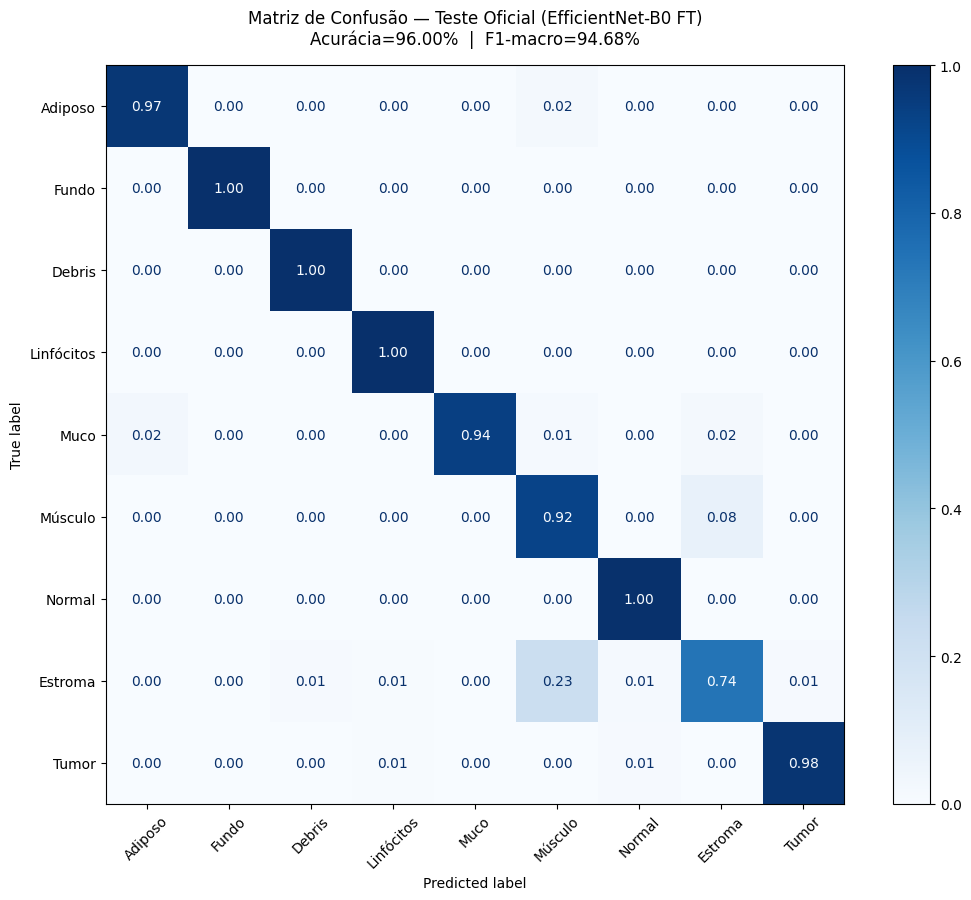

Salvo: 05_matriz_confusao.png


In [7]:
# ============================================================
# CÉLULA 6 — Matriz de Confusão 9×9 (normalizada por linha)
# ============================================================
matriz = confusion_matrix(todos_reais, todas_preds, normalize='true')

fig, ax = plt.subplots(figsize=(11, 9))
ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=NOMES_CLASSES,
).plot(cmap='Blues', ax=ax, xticks_rotation=45, values_format='.2f')

ax.set_title(
    f'Matriz de Confusão — Teste Oficial (EfficientNet-B0 FT)\n'
    f'Acurácia={acuracia:.2f}%  |  F1-macro={f1_macro:.2f}%',
    pad=15, fontsize=12,
)
plt.tight_layout()
plt.savefig('05_matriz_confusao.png', dpi=300, bbox_inches='tight')
plt.show()
print('Salvo: 05_matriz_confusao.png')

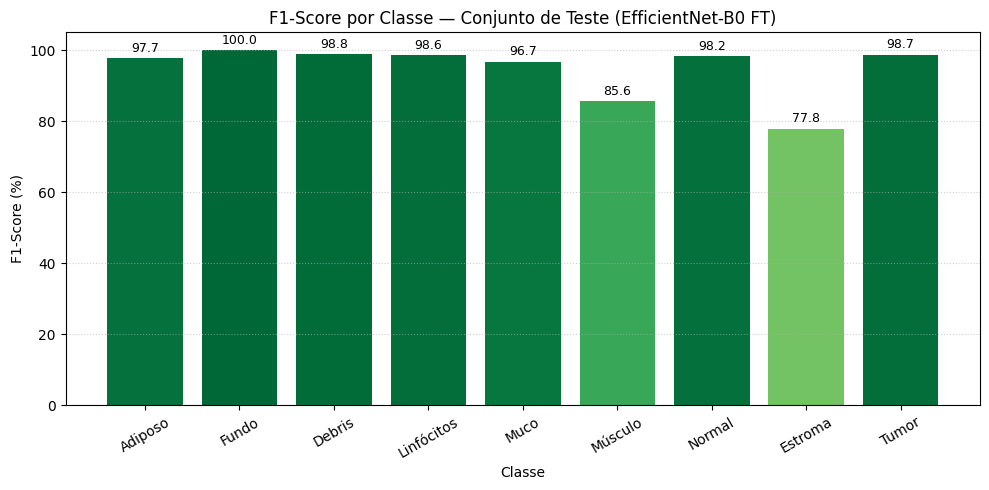

Salvo: 05_f1_por_classe.png


In [8]:
# ============================================================
# CÉLULA 7 — F1 por Classe
# ============================================================
f1_por_classe = f1_score(todos_reais, todas_preds, average=None) * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(NOMES_CLASSES, f1_por_classe,
              color=plt.cm.RdYlGn(f1_por_classe / 100))
ax.set_ylim(0, 105)
ax.set_xlabel('Classe')
ax.set_ylabel('F1-Score (%)')
ax.set_title('F1-Score por Classe — Conjunto de Teste (EfficientNet-B0 FT)', fontsize=12)
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, f1_por_classe):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f'{val:.1f}', ha='center', va='bottom', fontsize=9,
    )
ax.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('05_f1_por_classe.png', dpi=300, bbox_inches='tight')
plt.show()
print('Salvo: 05_f1_por_classe.png')